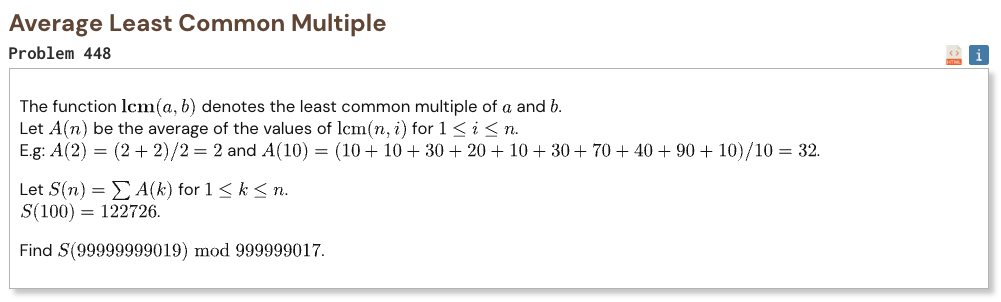

## Initial approach

-   rewrite each least common multiple using the gcd so the average can be grouped by common divisors
-   the sum of numbers coprime to a value is controlled by Euler's totient function
-   this changes the problem into summing d times phi of d over divisors
-   swap the order of summation so each divisor is counted for all of its multiples
-   group ranges where integer division by d has the same value because there are only about square root many different quotients
-   compute prefix sums of d times phi of d with a memoized recurrence instead of evaluating every value up to the huge limit
-   use array to store the sieve compactly because a normal Python integer list would use much more memory
-   perform every large calculation modulo 999999017

In [1]:
%%time

from array import array

N = 99_999_999_019
MOD = 999_999_017
LIMIT = 5_000_000

phi = array("I", range(LIMIT + 1))

for p in range(2, LIMIT + 1):
    if phi[p] == p:
        for k in range(p, LIMIT + 1, p):
            phi[k] -= phi[k] // p

total = 0

for k in range(1, LIMIT + 1):
    total = (total + k * phi[k]) % MOD
    phi[k] = total

cache = {}

def sum_integers(left, right):
    return ((left + right) * (right - left + 1) // 2) % MOD

def sum_squares(n):
    return (n * (n + 1) * (2 * n + 1) // 6) % MOD

def totient_weight_prefix(n):
    if n <= LIMIT:
        return phi[n]

    if n in cache:
        return cache[n]

    result = sum_squares(n)
    left = 2

    while left <= n:
        q = n // left
        right = n // q

        result -= (
            sum_integers(left, right)
            * totient_weight_prefix(q)
        )

        result %= MOD
        left = right + 1

    cache[n] = result
    return result

weighted_sum = 0
left = 1

while left <= N:
    q = N // left
    right = N // q

    block = (
        totient_weight_prefix(right)
        - totient_weight_prefix(left - 1)
    ) % MOD

    weighted_sum += q * block
    weighted_sum %= MOD

    left = right + 1

result = ((N + weighted_sum) // 2) % MOD

if (N + weighted_sum) % 2 != 0:
    result = (
        (N % MOD + weighted_sum)
        * pow(2, MOD - 2, MOD)
    ) % MOD

print("Result:", result)

Result: 106467648
CPU times: user 41.6 s, sys: 165 ms, total: 41.8 s
Wall time: 42.1 s
